In [10]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [11]:
# Load Dataset
movie = pd.read_csv("IMDb Movies India.csv", encoding="latin1")



In [12]:
# Display Data
print(movie.head())
print(movie.info())
print(movie.describe())
print(movie.isnull().sum())



                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

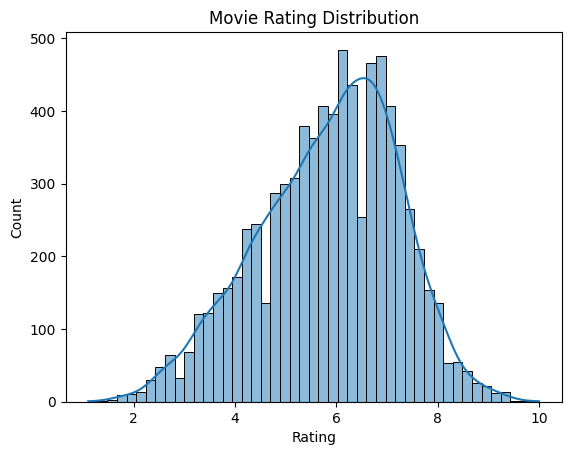

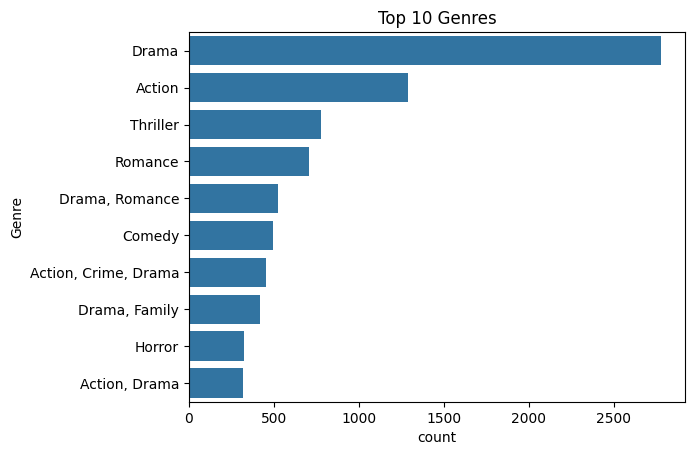

In [4]:
# ------------------ EDA ------------------

sns.histplot(movie["Rating"], kde=True)
plt.title("Movie Rating Distribution")
plt.show()

sns.countplot(y=movie["Genre"], order=movie["Genre"].value_counts().head(10).index)
plt.title("Top 10 Genres")
plt.show()


In [5]:

# ------------------ Data Preprocessing ------------------

# Keep only required columns
movie = movie[["Genre", "Director", "Actor 1", "Rating"]]

# Remove missing values
movie = movie.dropna()



In [6]:
# Convert text columns into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

movie["Genre"] = le.fit_transform(movie["Genre"])
movie["Director"] = le.fit_transform(movie["Director"])
movie["Actor 1"] = le.fit_transform(movie["Actor 1"])

# Input and Output
X = movie[["Genre", "Director", "Actor 1"]]
y = movie["Rating"]


In [7]:

# ------------------ Model ------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [8]:
# Prediction
y_pred = model.predict(X_test)



In [9]:
# Error
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

Mean Absolute Error: 1.1051493588148278
